In [497]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [498]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [499]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [500]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_track.txt', sep='\\s+')
df2 = pd.read_csv('./xschem/simulation/tb_boot.txt', sep='\\s+')
df2

,time,v(vi),v(vo)
0,1.800000e-09,0.336269,0.260650
1,3.800000e-09,0.375119,0.299212
2,5.800000e-09,0.410894,0.335155
3,7.800000e-09,0.442128,0.366993
4,9.800000e-09,0.467544,0.393425
...,...,...,...
535,6.380000e-08,0.379034,0.413110
536,6.580000e-08,0.202779,0.049954
537,6.780000e-08,0.414397,0.425020
538,6.980000e-08,0.169585,0.041772


In [501]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [502]:
vi_track = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo_track = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])
vi = np.reshape(df2['v(vi)'].values, [runs, len(df2)//runs])
vo = np.reshape(df2['v(vo)'].values, [runs, len(df2)//runs])

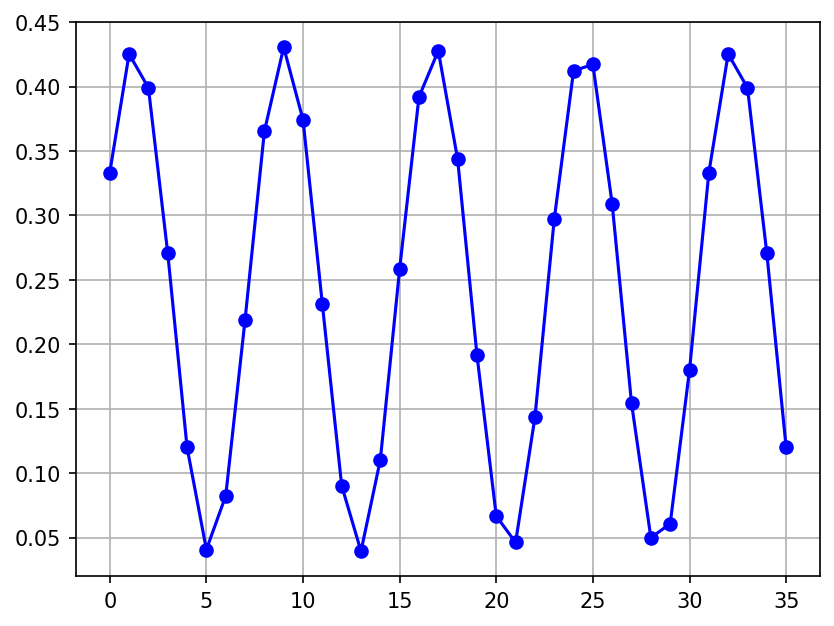

In [503]:
plt.plot(vo[3, :], "b-o")
plt.grid()
plt.show()

In [504]:
hd3_vi_track = compute_spectra(bins, vi_track, ndft)[1]
hd3_vo_track = compute_spectra(bins, vo_track, ndft)[1]
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-5.508064744357385e-11
3.1808298218475366e-10
-2.7330360195990877e-08
1.1552548411817843e-07
1.6614944821824175e-09
-5.172710667732829e-08
1.2664023089800063e-07
-3.887147726618499e-08
-1.327424387241161e-08
-2.8872547238205647e-09
-1.089024813007902e-07
6.820905389657157e-08
9.57395892524011e-09
5.515139697765851e-07
1.3243710197347845e-08
-5.238318012150778e-10
1.0864516087229279e-10
2.6941422895300632e-08
-1.628233198546088e-07
3.876760238654998e-09
1.2081328580270762e-07
7.478119553010681e-07
-4.7008089943790604e-07
4.0883581799430926e-08
2.1409211765496605e-09
-1.1262520204998855e-07
-1.2922694203979472e-07
4.438588905245286e-08
-9.87862592198713e-07
1.8866795024710254e-08
-7.540578199629234e-09
-1.7259230129198477e-07
-6.231031356346155e-08
-6.993366212902926e-10
-2.1368435035940153e-07
8.345960687414164e-06
-4.9233017122226984e-08
5.81957111703257e-08
-1.5190394962030532e-07
-1.2771843351462918e-06
-1.5939680595040913e-06
1.24592325331323e-07
-1.1099186109127815e-05
1.4586839551

In [505]:
# Analytical data
vov = 0.734
vm = 0.20
fs = 500e6
fin = bins*fs/ndft
c = 5e-12
cb = 1e-12
cp =  100e-15 + 2e-15
gds = 151e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb)**2)
print(fbw/1e6)

4806.479281375239


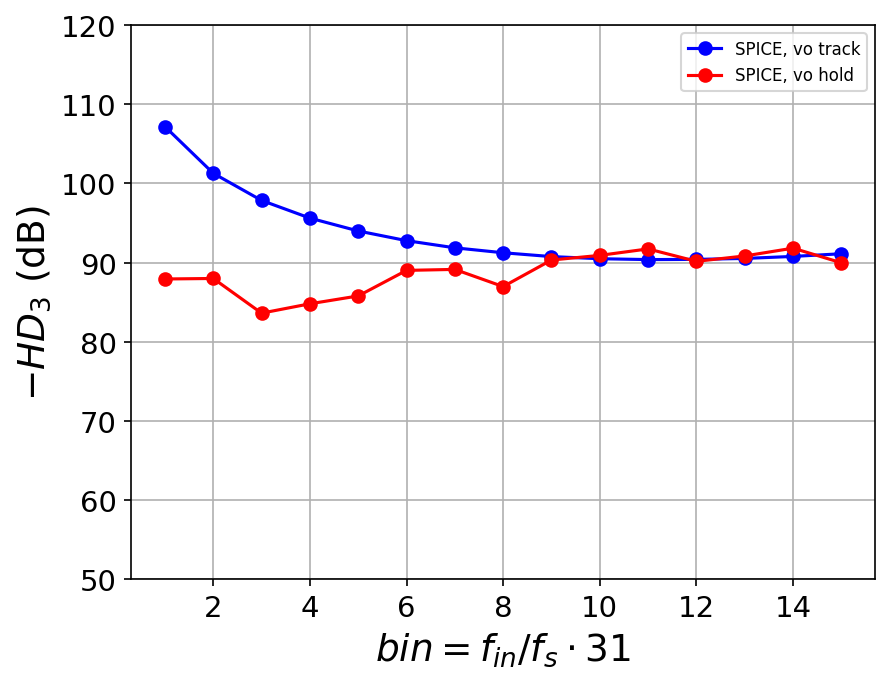

In [506]:
plt.rcParams['figure.dpi'] = 150
#plt.plot(bins, hd3_calc, "g--", label='Track-mode analysis')
#plt.plot(bins, hd3_vi_track, "b--", label='vi track')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo_track, "b-o", label='SPICE, vo track')
plt.plot(bins, hd3_vo, "r-o", label='SPICE, vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(50, 120)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

1.1654581529386088e-07
-1.5871684602580583e-06
1.4192624630764214e-06
-7.720184568969304e-06
7.277982611177271e-07
3.481387311460267e-07
1.1507034809716275e-05
-5.050035678372595e-06
1.185211625098173e-06
3.1213912016067715e-07
-5.654513977106675e-06
-3.3255319134157494e-06
5.319095479721941e-07
-3.749978957087345e-05
7.171035179711967e-06


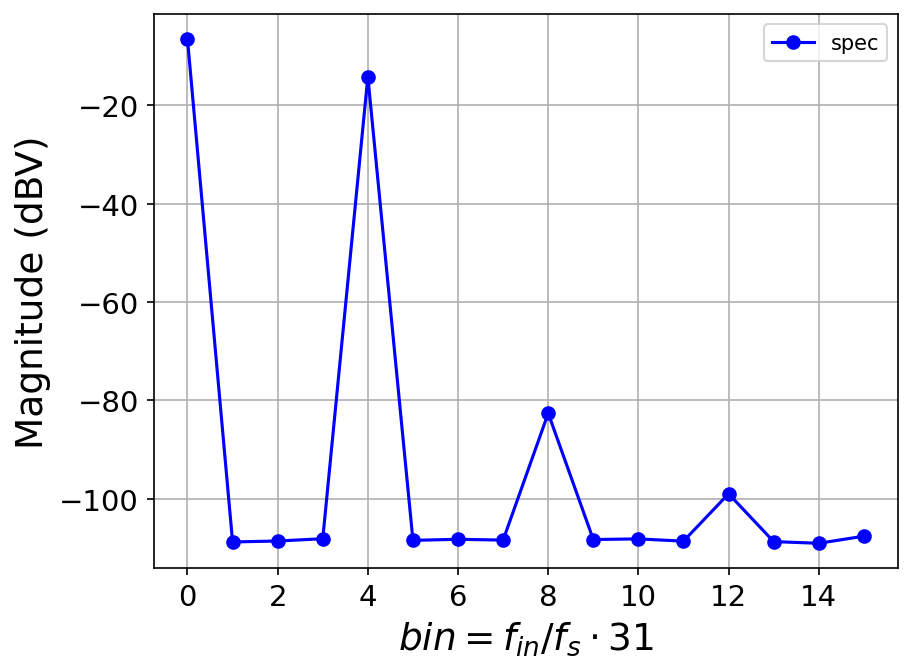

In [507]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
